# Proyecto: Riesgo postcompra de vehículos en Panamá

## Fase 1 — Exploración de ACODECO 2024–2025 + ADAP 2024–2025

En este notebook vamos a explorar las dos fuentes **poco a poco**, sin construir todavía ningún modelo.

La idea es comprobar primero:

1. Qué información tenemos en ACODECO para 2024 y 2025.
2. Qué registros de ACODECO son realmente comparables con las ventas de vehículos nuevos de ADAP.
3. Qué información contiene ADAP para 2024 y 2025.
4. Si podemos estandarizar las marcas y unir ambas fuentes.
5. Qué hallazgos aparecen después de la unión.

Por ahora **no vamos a definir Bajo/Medio/Alto ni entrenar modelos**. Primero queremos comprobar que la integración de las fuentes tiene sentido.


## 1. Importar librerías


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# PARTE A — EXPLORACIÓN DE ACODECO

Primero vamos a revisar por separado los archivos de reclamaciones de 2024 y 2025.


## 2. Cargar los archivos de ACODECO

Encontramos que los dos archivos usan `;` como separador, pero no tienen la misma codificación.

- 2024: `cp850`
- 2025: `latin1`


In [2]:
df_2024 = pd.read_csv(
    "decision-de-quejas-2024.csv",
    sep=";",
    encoding="cp850"
)

df_2025 = pd.read_csv(
    "decisionquejas_2025.csv",
    sep=";",
    encoding="latin1"
)


## 3. Revisar el tamaño de cada archivo


In [3]:
print("2024:", df_2024.shape)
print("2025:", df_2025.shape)


2024: (1915, 17)
2025: (2063, 17)


### Hallazgo

Antes de hacer cualquier filtro:

- 2024 contiene **1,915 registros y 17 columnas**.
- 2025 contiene **2,063 registros y 17 columnas**.

Los dos años tienen la misma cantidad de columnas, por lo que en principio se pueden unir verticalmente.


## 4. Ver los primeros registros de cada año


In [4]:
df_2024.head()


,Departamento de la Institución,Provincias dela República de Panamá,Tipo de Ley,Fecha de Entrada de Queja,Mes de Entrada de Queja,Motivo de Queja,Agente Económico,Actividad,Marca de Producto,Producto,Velor de Apertura de Queja,Resultado de Queja,Efectivo Devuelto al Consumidor (B/.),Fecha de Cierre de Queja,Mes Cierre de Queja,Año Cierre de Queja,Año Recibido de Queja
0,Decisión,Panamá,Ley 45 de 2007,45320,Ene 24,Incumplimiento de garantía,REDPRECIO.COM,Electrodomésticos/equipos electrónicos,HP,Computadora,213.99,Desistimiento/Devolución,213.99,45349.0,Feb 24,2024.0,2024
1,Vehículo a Motor,Panamá,Ley 45 de 2007,45299,Ene 24,Incumplimiento de garantía,BAHIA MOTORS,Agencia de autos,Honda,Auto,775.00,Acuerdo en audiencia/Varios,NaN,45378.0,Mar 24,2024.0,2024
2,Decisión,Panamá,Ley 45 de 2007,45295,Ene 24,Falta de información,"TINO RAMIREZ Y DANIEL, S.A.",Videojuegos,NaN,NaN,840.38,Desistimiento,NaN,45320.0,Ene 24,2024.0,2024
3,Vehículo a Motor,Panamá,Ley 45 de 2007,45301,Ene 24,Incumplimiento de garantía,"GRUPO AUTO COMERCIAL, S.A.",Agencia de autos,GAP,Auto,18750.00,Desistimiento,NaN,45462.0,Jun 24,2024.0,2024
4,Veracidad,Panamá,Ley 45 de 2007,45316,Ene 24,Veracidad de la publicidad,PRICESMART,Supermercados,NaN,NaN,559.99,En proceso,NaN,NaN,NaN,NaN,2024


In [5]:
df_2025.head()


,Departamento de la Institución,Provincias dela República de Panamá,Tipo de Ley,Fecha de Entrada de Queja,Mes de Entrada de Queja,Motivo de Queja,Agente Económico,Actividad,Marca de Producto,Producto,Velor de Apertura de Queja,Resultado de Queja,Efectivo Devuelto al Consumidor (B/.),Fecha de Cierre de Queja,Mes Cierre de Queja,Año Cierre de Queja,Año Recibido de Queja
0,Decisión,Panamá,Ley 45 de 2007,22-ene-2025,Ene 25,Incumplimiento de contrato,AUTOTODO PTY,Repuestos para autos,No se Registro,No se Registro,220.00,En proceso,NaN,NaN,NaN,NaN,2025
1,Vehículo a Motor,Panamá,Ley 14 de 2018,02-ene-2025,Ene 25,Incumplimiento de garantía,LA CASA DE AUTO REPUESTOS,Taller de reparación de autos,Daihatsu,Automóvil,64.20,Desistimiento,NaN,11-jun-2025,Jun 25,2025.0,2025
2,Decisión,Panamá,Ley 45 de 2007,06-ene-2025,Ene 25,Incumplimiento de garantía,TITAN PANAMÁ,Almacén por departamentos,No se Registro,No se Registro,385.19,Acuerdo en audiencia/Varios,NaN,05-feb-2025,Feb 25,2025.0,2025
3,Vehículo a Motor,Panamá,Ley 14 de 2018,02-ene-2025,Ene 25,Incumplimiento de garantía,GET A CAR,Venta de autos usados,Hyundai,Automóvil,"3,000.00",Pendiente constancia desistimiento,NaN,06-jun-2025,Jun 25,2025.0,2025
4,Decisión,Panamá,Ley 45 de 2007,06-ene-2025,Ene 25,Resolución de contrato,TIGO PANAMÁ,Telefonia,No se Registro,No se Registro,32.26,Acuerdo en audiencia/Varios,NaN,10-mar-2025,Mar 25,2025.0,2025


## 5. Comparar los nombres de las columnas


In [6]:
print("Columnas 2024:")
print(df_2024.columns.tolist())

print("\nColumnas 2025:")
print(df_2025.columns.tolist())

print("\n¿Tienen exactamente las mismas columnas?")
print(df_2024.columns.tolist() == df_2025.columns.tolist())


Columnas 2024:
['Departamento  de la Institución', 'Provincias dela República  de Panamá', 'Tipo de Ley', 'Fecha de Entrada de Queja', 'Mes de Entrada de Queja', 'Motivo de Queja', 'Agente Económico', 'Actividad', 'Marca de Producto', 'Producto', 'Velor de Apertura de Queja', 'Resultado de Queja', 'Efectivo Devuelto al Consumidor (B/.)', 'Fecha de Cierre de Queja', 'Mes Cierre de Queja', 'Año Cierre de Queja', 'Año Recibido de Queja']

Columnas 2025:
['Departamento  de la Institución', 'Provincias dela República  de Panamá', 'Tipo de Ley', 'Fecha de Entrada de Queja', 'Mes de Entrada de Queja', 'Motivo de Queja', 'Agente Económico', 'Actividad', 'Marca de Producto', 'Producto', 'Velor de Apertura de Queja', 'Resultado de Queja', 'Efectivo Devuelto al Consumidor (B/.)', 'Fecha de Cierre de Queja', 'Mes Cierre de Queja', 'Año Cierre de Queja', 'Año Recibido de Queja']

¿Tienen exactamente las mismas columnas?
True


### Hallazgo

Los archivos de 2024 y 2025 tienen **las mismas 17 columnas** y en el mismo orden.

Esto facilita la unión de ambos años.


## 6. Revisar los tipos de datos

Queremos detectar diferencias que puedan afectar la unión.


In [7]:
print("TIPOS 2024")
print(df_2024.dtypes)

print("\nTIPOS 2025")
print(df_2025.dtypes)


TIPOS 2024
Departamento  de la Institución           object
Provincias dela República  de Panamá      object
Tipo de Ley                               object
Fecha de Entrada de Queja                  int64
Mes de Entrada de Queja                   object
Motivo de Queja                           object
Agente Económico                          object
Actividad                                 object
Marca de Producto                         object
Producto                                  object
Velor de Apertura de Queja               float64
Resultado de Queja                        object
Efectivo Devuelto al Consumidor (B/.)    float64
Fecha de Cierre de Queja                 float64
Mes Cierre de Queja                       object
Año Cierre de Queja                      float64
Año Recibido de Queja                      int64
dtype: object

TIPOS 2025
Departamento  de la Institución           object
Provincias dela República  de Panamá      object
Tipo de Ley                     

### Hallazgo importante

La columna `Fecha de Entrada de Queja` no viene igual en ambos años:

- En 2024 aparece como un número de Excel.
- En 2025 aparece como texto, por ejemplo `22-ene-2025`.

Por ahora no necesitamos transformar esa fecha porque los archivos ya contienen el año y el mes de la reclamación. Si posteriormente necesitamos trabajar con fechas exactas, tendremos que estandarizarlas.


## 7. Agregar una columna para identificar el año de origen


In [8]:
df_2024["anio"] = 2024
df_2025["anio"] = 2025


## 8. Unir ACODECO 2024 y 2025


In [9]:
quejas = pd.concat(
    [df_2024, df_2025],
    ignore_index=True
)

quejas.shape


(3978, 18)

In [10]:
quejas["anio"].value_counts().sort_index()


anio
2024    1915
2025    2063
Name: count, dtype: int64

### Hallazgo

Después de unir los dos archivos tenemos **3,978 reclamaciones** de ACODECO entre 2024 y 2025.

Todavía aquí están mezclados todos los departamentos de ACODECO.


## 9. Revisar los departamentos por año


In [11]:
pd.crosstab(
    quejas["Departamento  de la Institución"],
    quejas["anio"]
)


anio,2024,2025
Departamento de la Institución,,
Decisión,1518,1504
Vehículo a Motor,387,537
Veracidad,10,22


### Hallazgo

El departamento que nos interesa es `Vehículo a Motor`.

Encontramos:

- **387 reclamaciones** de Vehículo a Motor en 2024.
- **537 reclamaciones** de Vehículo a Motor en 2025.


## 10. Filtrar solamente Vehículo a Motor


In [12]:
vehiculos = quejas[
    quejas["Departamento  de la Institución"] == "Vehículo a Motor"
].copy()

vehiculos.shape


(924, 18)

In [13]:
vehiculos["anio"].value_counts().sort_index()


anio
2024    387
2025    537
Name: count, dtype: int64

### Hallazgo

Al unir 2024 y 2025 tenemos **924 reclamaciones del departamento Vehículo a Motor**.

Este será nuestro conjunto principal para conocer primero qué tipos de reclamaciones existen en ACODECO.


## 11. Revisar valores faltantes


In [14]:
nulos = pd.DataFrame({
    "cantidad_nulos": vehiculos.isnull().sum(),
    "porcentaje": (vehiculos.isnull().mean() * 100).round(2)
})

nulos.sort_values("porcentaje", ascending=False)


,cantidad_nulos,porcentaje
Efectivo Devuelto al Consumidor (B/.),911,98.59
Mes Cierre de Queja,789,85.39
Fecha de Cierre de Queja,789,85.39
Año Cierre de Queja,789,85.39
Marca de Producto,64,6.93
Producto,19,2.06
Provincias dela República de Panamá,0,0.00
Departamento de la Institución,0,0.00
Tipo de Ley,0,0.00
Fecha de Entrada de Queja,0,0.00


### Hallazgo

Las columnas con mayor cantidad de faltantes son las relacionadas con el cierre de las quejas:

- `Efectivo Devuelto al Consumidor`: alrededor de **98.6%**.
- Fecha, mes y año de cierre: alrededor de **85.4%**.

También encontramos registros donde no se identificó la marca.

Estos faltantes no impiden por ahora comparar reclamaciones y ventas, porque para esa comparación nos interesan principalmente el año, actividad, producto y marca.


## 12. Revisar las actividades del sector Vehículo a Motor


In [15]:
vehiculos["Actividad"].value_counts()


Actividad
Agencia de autos                                       332
Venta de autos usados                                  218
Taller de reparación de autos                          159
Repuestos para autos                                   115
Agencia de motos                                        25
Estaciones de gasolinas                                 17
Alquiler de autos                                       16
Servicios de grúas                                       7
Repuestos y reparaciones (talleres varios no autos)      7
Servicios de instalación                                 6
Lavautos                                                 4
Almacén por departamentos                                4
Servicio de intermediación                               3
Ferreterías, materiales de construccion o similares      3
Transporte (fletes, encomiendas y similares)             1
Almacén de ropa y calzados                               1
Envío de dinero                               

### Hallazgo

Las 924 reclamaciones no corresponden solamente a vehículos nuevos.

Dentro del departamento aparecen actividades como:

- Agencia de autos
- Venta de autos usados
- Taller de reparación de autos
- Repuestos para autos
- Agencia de motos
- Alquiler de autos
- Estaciones de gasolina

Esto es importante porque **ADAP reporta ventas de vehículos nuevos**. Por lo tanto, más adelante no sería correcto dividir todas estas reclamaciones entre las ventas nuevas de ADAP.


## 13. Comparar actividades entre 2024 y 2025


In [16]:
pd.crosstab(
    vehiculos["Actividad"],
    vehiculos["anio"]
).sort_values(by=2025, ascending=False).head(15)


anio,2024,2025
Actividad,,
Agencia de autos,149,183
Venta de autos usados,81,137
Taller de reparación de autos,64,95
Repuestos para autos,45,70
Agencia de motos,8,17
Estaciones de gasolinas,7,10
Repuestos y reparaciones (talleres varios no autos),1,6
Servicios de grúas,2,5
Servicios de instalación,3,3


### Hallazgo

`Agencia de autos` es la actividad con más registros relacionados directamente con distribuidores de vehículos:

- 2024: **149**
- 2025: **183**

Sin embargo, todavía debemos revisar el producto porque dentro de una agencia también pueden existir reclamaciones por repuestos, motos u otros artículos.


## 14. Revisar los motivos de queja


In [17]:
vehiculos["Motivo de Queja"].value_counts()


Motivo de Queja
Incumplimiento de garantía    559
Falta de información          119
Incumplimiento de servicio    115
Custodia de bien               58
Devolución de dinero           23
Incumplimiento de contrato     16
Vicio oculto                   12
Daños y perjuicios             11
Cobro indebido                  5
Venta engañosa                  4
Veracidad de la publicidad      1
Mercancía defectuosa            1
Name: count, dtype: int64

In [18]:
pd.crosstab(
    vehiculos["Motivo de Queja"],
    vehiculos["anio"]
).sort_values(by=2025, ascending=False)


anio,2024,2025
Motivo de Queja,,
Incumplimiento de garantía,237,322
Falta de información,50,69
Incumplimiento de servicio,49,66
Custodia de bien,25,33
Devolución de dinero,6,17
Vicio oculto,3,9
Incumplimiento de contrato,10,6
Daños y perjuicios,5,6
Cobro indebido,1,4


### Hallazgo

El principal motivo de queja en ambos años es `Incumplimiento de garantía`.

En el conjunto 2024–2025 aparecen **559 reclamaciones** con este motivo.

Por ahora esto es solamente descriptivo; no estamos utilizando todavía el motivo para construir ninguna clasificación.


## 15. Revisar las marcas registradas


In [19]:
vehiculos["Marca de Producto"].value_counts(dropna=False).head(30)


Marca de Producto
Hyundai           104
Toyota            103
KIA               100
No se Registro     83
Nissan             79
NaN                64
Chevrolet          51
Suzuki             36
Honda              30
Ford               23
Changan            21
Mitsubishi         19
GAC                16
Jetour             15
Mazda              14
Cherry             11
MG                 10
Geely              10
BMW                 9
Kaiyi               8
JEEP                7
Audi                7
Xmotors             6
Mercedez Benz       5
Volkswagen          5
Forthing            5
Dongfeng            5
Land Rover          5
Volvo               5
Isuzu               4
Name: count, dtype: int64

### Hallazgo

Entre las marcas con más reclamaciones registradas aparecen Hyundai, Toyota, KIA, Nissan y Chevrolet.

También observamos dos formas de falta de información:

- En 2024 existen marcas vacías (`NaN`).
- En 2025 aparece el texto `No se Registro`.

Más adelante tendremos que tratar ambos casos como **marca no identificada**.

La cantidad de reclamaciones por sí sola todavía **no indica riesgo**, porque las marcas tienen diferentes volúmenes de ventas.


## 16. Comparar las principales marcas entre años


In [20]:
pd.crosstab(
    vehiculos["Marca de Producto"],
    vehiculos["anio"]
).sort_values(by=2025, ascending=False).head(25)


anio,2024,2025
Marca de Producto,,
No se Registro,0,83
Hyundai,48,56
KIA,45,55
Toyota,49,54
Nissan,30,49
Chevrolet,29,22
Suzuki,15,21
Honda,11,19
Ford,5,18


## 17. Revisar los productos


In [21]:
vehiculos["Producto"].value_counts(dropna=False).head(25)


Producto
Automóvil             475
Auto                  334
Pieza de Repuesto      32
Moto                   24
NaN                    19
No se Registro         15
Batería de auto        10
Llanta                  3
Motor de Auto           2
Amortiguadores          2
Transmisión             2
Computadora             1
Combustible             1
#¡NULO!                 1
Aire acondicionado      1
Disco de frenos         1
Compresor de aire       1
Name: count, dtype: int64

In [22]:
pd.crosstab(
    vehiculos["Producto"],
    vehiculos["anio"]
).sort_values(by=2025, ascending=False).head(20)


anio,2024,2025
Producto,,
Automóvil,0,475
Pieza de Repuesto,14,18
No se Registro,0,15
Moto,10,14
Batería de auto,4,6
Motor de Auto,0,2
Amortiguadores,0,2
Transmisión,0,2
Compresor de aire,0,1


### Hallazgo importante

Encontramos una diferencia de escritura entre los años:

- En 2024 el vehículo aparece principalmente como `Auto`.
- En 2025 aparece como `Automóvil`.

Son categorías equivalentes para nuestro análisis, por lo que vamos a estandarizarlas.


## 18. Crear una versión estandarizada del producto


In [23]:
vehiculos["producto_std"] = (
    vehiculos["Producto"]
    .astype("string")
    .str.strip()
    .str.upper()
)

vehiculos["producto_std"] = vehiculos["producto_std"].replace({
    "AUTO": "AUTOMOVIL",
    "AUTOMÓVIL": "AUTOMOVIL"
})

vehiculos["producto_std"].value_counts(dropna=False).head(20)


producto_std
AUTOMOVIL             809
PIEZA DE REPUESTO      32
MOTO                   24
<NA>                   19
NO SE REGISTRO         15
BATERÍA DE AUTO        10
LLANTA                  3
MOTOR DE AUTO           2
AMORTIGUADORES          2
TRANSMISIÓN             2
COMPUTADORA             1
COMBUSTIBLE             1
#¡NULO!                 1
AIRE ACONDICIONADO      1
DISCO DE FRENOS         1
COMPRESOR DE AIRE       1
Name: count, dtype: Int64

### Hallazgo

Después de la estandarización, `Auto` y `Automóvil` quedan bajo una misma categoría: `AUTOMOVIL`.

Esto nos permite comparar ambos años de manera consistente.


## 19. Revisar los resultados de las quejas


In [24]:
vehiculos["Resultado de Queja"].value_counts()


Resultado de Queja
En proceso                                   789
Desistimiento                                 80
Pendiente constancia desistimiento            15
Acuerdo en audiencia/Devolución de dinero     11
Acuerdo en audiencia/Varios                    9
Desistimiento/Devolución                       7
Inhibe                                         6
Transacción extrajudicial                      2
Abandono                                       1
Ministerio Público                             1
Ordena corrección                              1
Acuerdo en audiencia/Reparación                1
Inadmitida                                     1
Name: count, dtype: int64

### Hallazgo

La mayoría de las reclamaciones todavía aparece como `En proceso`:

- 789 de 924 registros.

Por esta razón no vamos a utilizar el resultado de la queja para sacar conclusiones sobre el riesgo en esta fase.


## 20. Revisar las provincias


In [25]:
vehiculos["Provincias dela República  de Panamá"].value_counts()


Provincias dela República  de Panamá
Panamá        746
Pmá Oeste      56
Chiriquí       51
Herrera        25
Veraguas       17
Coclé          15
Los Santos      9
Colón           4
Darién          1
Name: count, dtype: int64

### Hallazgo

La mayoría de las reclamaciones se concentra en Panamá.

Esto también es descriptivo y no significa necesariamente que allí exista mayor riesgo, porque también existe una mayor concentración de población, comercios y vehículos.


## 21. Convertir el valor de apertura a número


In [26]:
vehiculos["valor_queja"] = pd.to_numeric(
    vehiculos["Velor de Apertura de Queja"]
        .astype(str)
        .str.replace(",", "", regex=False),
    errors="coerce"
)

vehiculos.groupby("anio")["valor_queja"].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
anio,,,,,,,,
2024,387.0,8586.16,9397.62,0.0,604.02,4000.0,16925.0,30000.0
2025,537.0,8912.83,9478.12,0.0,700.00,4300.0,18121.0,30000.0


### Hallazgo

El valor de apertura está disponible para las 924 reclamaciones.

La mediana fue aproximadamente:

- 2024: **B/. 4,000**
- 2025: **B/. 4,300**

Por ahora solamente estamos conociendo esta variable; todavía no la utilizaremos para crear ningún modelo.


## 22. Gráfico de las marcas con más reclamaciones


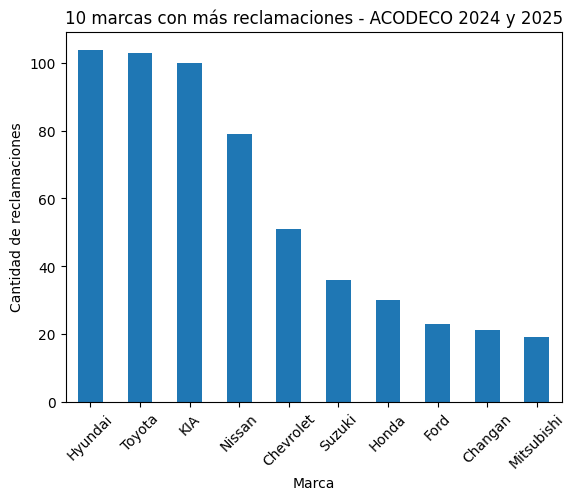

In [27]:
(
    vehiculos[
        vehiculos["Marca de Producto"].notna()
        & (vehiculos["Marca de Producto"] != "No se Registro")
    ]["Marca de Producto"]
    .value_counts()
    .head(10)
    .plot(kind="bar")
)

plt.title("10 marcas con más reclamaciones - ACODECO 2024 y 2025")
plt.xlabel("Marca")
plt.ylabel("Cantidad de reclamaciones")
plt.xticks(rotation=45)
plt.show()


### Primer hallazgo general de ACODECO

Ya comprobamos algo importante:

**No debemos utilizar las 924 reclamaciones completas directamente contra ADAP**, porque el conjunto incluye autos usados, talleres, repuestos, motos y otros servicios.

Antes de comparar con ventas de vehículos nuevos necesitamos construir un subconjunto que sea más comparable con ADAP.


# PARTE B — PREPARAR UN SUBCONJUNTO COMPARABLE CON ADAP

ADAP reporta **ventas de vehículos nuevos por marca**.

Para esta primera prueba vamos a trabajar solamente con reclamaciones que cumplen:

1. `Actividad = Agencia de autos`
2. `Producto = Automóvil` después de estandarizar Auto/Automóvil.

Esto no garantiza por sí solo que conocemos el año exacto de compra del vehículo, pero evita mezclar ventas nuevas con reclamaciones de talleres, repuestos o autos usados.


## 23. Crear el subconjunto comparable


In [28]:
reclamos_comparables = vehiculos[
    (vehiculos["Actividad"] == "Agencia de autos")
    & (vehiculos["producto_std"] == "AUTOMOVIL")
].copy()

reclamos_comparables.shape


(321, 20)

In [29]:
reclamos_comparables["anio"].value_counts().sort_index()


anio
2024    144
2025    177
Name: count, dtype: int64

### Hallazgo

El subconjunto más comparable con las ventas de ADAP contiene **321 reclamaciones**:

- 2024: **144**
- 2025: **177**

Este subconjunto es mucho más específico que las 924 reclamaciones iniciales.


## 24. Revisar las marcas de este subconjunto


In [30]:
pd.crosstab(
    reclamos_comparables["Marca de Producto"],
    reclamos_comparables["anio"]
).sort_values(by=2025, ascending=False)


anio,2024,2025
Marca de Producto,,
Hyundai,10,15
Jetour,0,15
Toyota,15,13
No se Registro,0,13
Changan,6,11
Chevrolet,22,11
Nissan,7,11
KIA,18,10
Kaiyi,0,8


### Hallazgo

Todavía existen problemas de calidad que debemos resolver antes de unir:

- marcas sin registrar;
- diferencias entre mayúsculas y minúsculas;
- nombres abreviados;
- algunas marcas escritas de forma diferente entre ACODECO y ADAP.


## 25. Estandarizar los nombres de las marcas de ACODECO


In [31]:
reclamos_comparables["marca_original"] = reclamos_comparables["Marca de Producto"]

reclamos_comparables["marca_std"] = (
    reclamos_comparables["Marca de Producto"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Unificamos la forma usada para marcas no identificadas
reclamos_comparables["marca_std"] = reclamos_comparables["marca_std"].replace({
    "NO SE REGISTRO": pd.NA
})

# Correcciones de nombres que aparecen diferentes entre ACODECO y ADAP
mapa_marcas = {
    "CHERRY": "CHERY",
    "CHERY QQ": "CHERY",
    "GAC": "GAC MOTOR",
    "DONGFENG": "DONG FENG",
    "MERCEDEZ BENZ": "MERCEDES BENZ"
}

reclamos_comparables["marca_std"] = (
    reclamos_comparables["marca_std"]
    .replace(mapa_marcas)
)

reclamos_comparables[
    ["marca_original", "marca_std"]
].drop_duplicates().sort_values("marca_std")


,marca_original,marca_std
691,Ava,AVA
2410,Bestune,BESTUNE
1528,BMW,BMW
369,Changan,CHANGAN
3678,Chery QQ,CHERY
543,Cherry,CHERY
117,Chevrolet,CHEVROLET
3804,DFSK,DFSK
530,Dongfeng,DONG FENG
2922,Fiat,FIAT


### Hallazgo

La estandarización no cambia el número de reclamaciones. Solamente crea una columna nueva para intentar hacer coincidir los nombres entre las dos fuentes.

Conservamos también `marca_original` para poder revisar siempre cómo venía escrito el dato original.


## 26. Resumir las reclamaciones por año y marca


In [32]:
quejas_marca_anio = (
    reclamos_comparables[
        reclamos_comparables["marca_std"].notna()
    ]
    .groupby(["anio", "marca_std"])
    .size()
    .reset_index(name="cantidad_quejas")
)

quejas_marca_anio.sort_values(
    ["anio", "cantidad_quejas"],
    ascending=[True, False]
).head(30)


,anio,marca_std,cantidad_quejas
4,2024,CHEVROLET,22
17,2024,KIA,18
26,2024,TOYOTA,15
12,2024,HYUNDAI,10
22,2024,NISSAN,7
25,2024,SUZUKI,7
2,2024,CHANGAN,6
8,2024,GAC MOTOR,6
7,2024,FORTHING,5
15,2024,JEEP,4


# PARTE C — EXPLORACIÓN DE ADAP

Ahora vamos a revisar por separado la tabla construida a partir del reporte anual de ADAP.

El archivo contiene ventas por marca para **2024 y 2025**, por lo que podemos comparar ambos años con ACODECO.


## 27. Cargar ADAP


In [33]:
adap = pd.read_csv("ADAP_Ventas_Marcas_2025.csv")

adap.shape


(41, 6)

### Hallazgo

ADAP contiene **41 filas y 6 columnas**.

Cada fila representa una marca del ranking, más una fila agregada llamada `OTRAS MARCAS`.


## 28. Ver los primeros registros


In [34]:
adap.head()


,ranking,marca,total_2025,total_2024,variacion_pct,participacion_pct
0,1.0,TOYOTA,11507,11189.0,2.8,19.1
1,2.0,KIA,7626,7457.0,2.3,12.7
2,3.0,HYUNDAI,6985,7048.0,-0.9,11.6
3,4.0,GEELY,3138,2345.0,33.8,5.2
4,5.0,SUZUKI,3094,2657.0,16.4,5.1


## 29. Revisar columnas y tipos


In [35]:
print(adap.columns)
print()
adap.info()


Index(['ranking', 'marca', 'total_2025', 'total_2024', 'variacion_pct',
       'participacion_pct'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ranking            40 non-null     float64
 1   marca              41 non-null     object 
 2   total_2025         41 non-null     int64  
 3   total_2024         40 non-null     float64
 4   variacion_pct      40 non-null     float64
 5   participacion_pct  41 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.1+ KB


## 30. Revisar valores faltantes


In [36]:
pd.DataFrame({
    "nulos": adap.isnull().sum(),
    "porcentaje": (adap.isnull().mean() * 100).round(2)
})


,nulos,porcentaje
ranking,1,2.44
marca,0,0.00
total_2025,0,0.00
total_2024,1,2.44
variacion_pct,1,2.44
participacion_pct,0,0.00


### Hallazgo

Los únicos faltantes corresponden a la fila `OTRAS MARCAS` en variables que dependen del ranking o de información individual del año anterior.

Las columnas de ventas 2025 y participación están completas.


## 31. Validar el total de ventas de cada año


In [37]:
total_2024 = adap["total_2024"].sum()
total_2025 = adap["total_2025"].sum()

print("Ventas 2024:", total_2024)
print("Ventas 2025:", total_2025)

crecimiento = ((total_2025 - total_2024) / total_2024) * 100
print("Crecimiento 2024 a 2025:", round(crecimiento, 2), "%")


Ventas 2024: 54384.0
Ventas 2025: 60233
Crecimiento 2024 a 2025: 10.76 %


### Hallazgo

La suma del archivo de ADAP da:

- 2024: **54,384 vehículos**
- 2025: **60,233 vehículos**

Entre ambos años las ventas aumentaron aproximadamente **10.76%**.


## 32. Revisar las marcas con mayores ventas


In [38]:
print("TOP 10 - 2024")
display(
    adap[["marca", "total_2024"]]
    .sort_values("total_2024", ascending=False)
    .head(10)
)

print("TOP 10 - 2025")
display(
    adap[["marca", "total_2025"]]
    .sort_values("total_2025", ascending=False)
    .head(10)
)


TOP 10 - 2024


,marca,total_2024
0,TOYOTA,11189.0
1,KIA,7457.0
2,HYUNDAI,7048.0
4,SUZUKI,2657.0
6,NISSAN,2417.0
3,GEELY,2345.0
5,MITSUBISHI,2233.0
8,CHANGAN,1736.0
9,ISUZU,1584.0
40,OTRAS MARCAS,1552.0


TOP 10 - 2025


,marca,total_2025
0,TOYOTA,11507
1,KIA,7626
2,HYUNDAI,6985
3,GEELY,3138
4,SUZUKI,3094
5,MITSUBISHI,2185
6,NISSAN,2166
7,JETOUR,1999
8,CHANGAN,1854
9,ISUZU,1747


### Hallazgo

Toyota, KIA y Hyundai se mantienen entre las marcas con mayor volumen de ventas.

Esto confirma por qué no debemos comparar marcas usando solamente el número bruto de reclamaciones: las marcas tienen exposiciones de ventas muy diferentes.


## 33. Revisar participación de mercado y variación


In [39]:
adap[
    ["marca", "total_2024", "total_2025", "variacion_pct", "participacion_pct"]
].sort_values("total_2025", ascending=False).head(20)


,marca,total_2024,total_2025,variacion_pct,participacion_pct
0,TOYOTA,11189.0,11507,2.80,19.1
1,KIA,7457.0,7626,2.30,12.7
2,HYUNDAI,7048.0,6985,-0.90,11.6
3,GEELY,2345.0,3138,33.80,5.2
4,SUZUKI,2657.0,3094,16.40,5.1
5,MITSUBISHI,2233.0,2185,-2.10,3.6
6,NISSAN,2417.0,2166,-10.40,3.6
7,JETOUR,1264.0,1999,58.10,3.3
8,CHANGAN,1736.0,1854,6.80,3.1
9,ISUZU,1584.0,1747,10.30,2.9


### Hallazgo

ADAP también nos permite observar cuánto cambió el volumen de ventas de cada marca entre 2024 y 2025.

Esta información será útil más adelante para estudiar si una variación en ventas puede afectar la interpretación de las reclamaciones.


## 34. Gráfico de ventas 2024 vs 2025


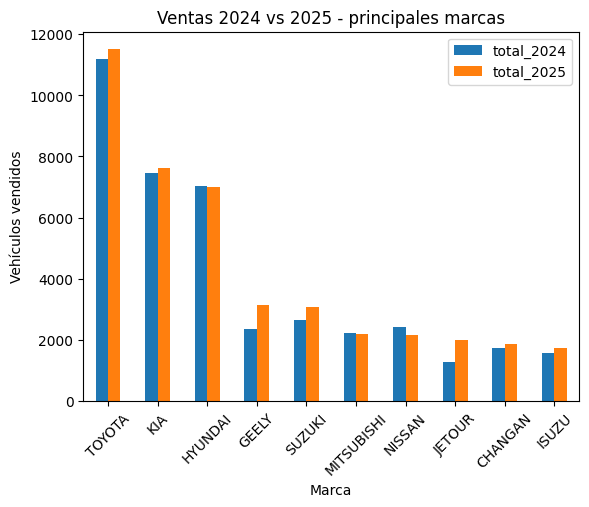

In [40]:
top10_adap = (
    adap[adap["marca"] != "OTRAS MARCAS"]
    .sort_values("total_2025", ascending=False)
    .head(10)
)

top10_adap[
    ["marca", "total_2024", "total_2025"]
].set_index("marca").plot(kind="bar")

plt.title("Ventas 2024 vs 2025 - principales marcas")
plt.xlabel("Marca")
plt.ylabel("Vehículos vendidos")
plt.xticks(rotation=45)
plt.show()


## 35. Revisar los nombres de las marcas de ADAP


In [41]:
adap["marca"].tolist()


['TOYOTA',
 'KIA',
 'HYUNDAI',
 'GEELY',
 'SUZUKI',
 'MITSUBISHI',
 'NISSAN',
 'JETOUR',
 'CHANGAN',
 'ISUZU',
 'FORD',
 'MAZDA',
 'FORTHING',
 'GAC MOTOR',
 'HONDA',
 'KAIYI',
 'CHERY',
 'DONG FENG',
 'CHEVROLET',
 'BMW',
 'LEXUS',
 'BYD',
 'GREAT WALL',
 'JAECOO',
 'MG',
 'JIMC',
 'HINO',
 'SUBARU',
 'VOLKSWAGEN',
 'SOUEAST',
 'OMODA',
 'MERCEDES BENZ',
 'AUDI',
 'FOTON',
 'JAC',
 'MAXUS',
 'DODGE',
 'LAND ROVER',
 'PORSCHE',
 'VOLVO',
 'OTRAS MARCAS']

### Hallazgo

ADAP incluye una categoría agregada llamada `OTRAS MARCAS`.

No podemos utilizar esa fila para asignarle ventas a una marca específica de ACODECO. Si una marca aparece en ACODECO pero no aparece individualmente en ADAP, la dejaremos como **no coincidente** en esta primera prueba.


# PARTE D — PROBAR LA UNIÓN ENTRE ACODECO Y ADAP

Ahora queremos comprobar si las marcas estandarizadas de ACODECO pueden relacionarse con las marcas de ADAP.


## 36. Revisar qué marcas coinciden


In [42]:
marcas_adap = set(
    adap.loc[
        adap["marca"] != "OTRAS MARCAS",
        "marca"
    ]
)

reclamos_comparables["coincide_adap"] = (
    reclamos_comparables["marca_std"].isin(marcas_adap)
)

reclamos_comparables["coincide_adap"].value_counts()


coincide_adap
True     274
False     47
Name: count, dtype: int64

In [43]:
total_comparable = len(reclamos_comparables)
coinciden = reclamos_comparables["coincide_adap"].sum()

identificables = reclamos_comparables["marca_std"].notna().sum()
coinciden_identificables = (
    reclamos_comparables[
        reclamos_comparables["marca_std"].notna()
    ]["coincide_adap"].sum()
)

print("Reclamaciones comparables:", total_comparable)
print("Coinciden directamente con ADAP:", coinciden)
print("Cobertura sobre el total:", round(coinciden / total_comparable * 100, 2), "%")
print("Marcas identificables:", identificables)
print(
    "Cobertura entre reclamaciones con marca identificada:",
    round(coinciden_identificables / identificables * 100, 2),
    "%"
)


Reclamaciones comparables: 321
Coinciden directamente con ADAP: 274
Cobertura sobre el total: 85.36 %
Marcas identificables: 298
Cobertura entre reclamaciones con marca identificada: 91.95 %


### Hallazgo

De las **321 reclamaciones comparables**, **274** pueden relacionarse con una marca individual de ADAP.

Eso representa:

- **85.36%** de todas las reclamaciones comparables.
- Aproximadamente **91.95%** si consideramos solamente los registros donde la marca sí fue identificada.

Esto indica que **la unión es técnicamente viable**, aunque todavía existen marcas que debemos revisar.


## 37. Revisar qué registros no logran coincidir


In [44]:
(
    reclamos_comparables.loc[
        ~reclamos_comparables["coincide_adap"],
        "marca_std"
    ]
    .value_counts(dropna=False)
)


marca_std
<NA>           23
JEEP            5
PEUGEOT         3
KARRY           3
FIAT            2
VGV             2
YEMA            1
AVA             1
MINI COOPER     1
GAP             1
POER            1
BESTUNE         1
RAM             1
HAVAL           1
DFSK            1
Name: count, dtype: Int64

### Hallazgo

Las principales causas de no coincidencia son:

1. Marca no registrada en ACODECO.
2. Marcas que no aparecen individualmente en el ranking de ADAP.
3. Algunas marcas que posiblemente están dentro de `OTRAS MARCAS`, pero ADAP no proporciona su venta individual.

No vamos a inventar ventas para esas marcas. Se mantienen fuera de la comparación por marca hasta tener una fuente individual.


## 38. Pasar ADAP a formato año-marca

En ACODECO tenemos una fila resumida por marca y año.

Para unir las fuentes nos conviene transformar ADAP a la misma estructura:

`año | marca | ventas`


In [45]:
adap_2024 = (
    adap[
        (adap["marca"] != "OTRAS MARCAS")
        & adap["total_2024"].notna()
    ][["marca", "total_2024"]]
    .rename(columns={"total_2024": "ventas"})
)

adap_2024["anio"] = 2024

adap_2025 = (
    adap[
        adap["marca"] != "OTRAS MARCAS"
    ][["marca", "total_2025"]]
    .rename(columns={"total_2025": "ventas"})
)

adap_2025["anio"] = 2025

adap_anual = pd.concat(
    [adap_2024, adap_2025],
    ignore_index=True
)

adap_anual.head()


,marca,ventas,anio
0,TOYOTA,11189.0,2024
1,KIA,7457.0,2024
2,HYUNDAI,7048.0,2024
3,GEELY,2345.0,2024
4,SUZUKI,2657.0,2024


## 39. Volver a resumir solo las reclamaciones que sí coinciden con ADAP


In [46]:
quejas_marca_anio_match = (
    reclamos_comparables[
        reclamos_comparables["coincide_adap"]
    ]
    .groupby(["anio", "marca_std"])
    .size()
    .reset_index(name="cantidad_quejas")
)

quejas_marca_anio_match.head()


,anio,marca_std,cantidad_quejas
0,2024,BMW,1
1,2024,CHANGAN,6
2,2024,CHERY,3
3,2024,CHEVROLET,22
4,2024,DONG FENG,2


## 40. Unir reclamaciones y ventas


In [47]:
comparacion = quejas_marca_anio_match.merge(
    adap_anual,
    left_on=["anio", "marca_std"],
    right_on=["anio", "marca"],
    how="left"
)

comparacion.shape


(44, 5)

In [48]:
comparacion[
    ["anio", "marca", "cantidad_quejas", "ventas"]
].sort_values(
    ["anio", "cantidad_quejas"],
    ascending=[True, False]
).head(30)


,anio,marca,cantidad_quejas,ventas
3,2024,CHEVROLET,22,426.0
13,2024,KIA,18,7457.0
19,2024,TOYOTA,15,11189.0
10,2024,HYUNDAI,10,7048.0
17,2024,NISSAN,7,2417.0
18,2024,SUZUKI,7,2657.0
1,2024,CHANGAN,6,1736.0
7,2024,GAC MOTOR,6,1129.0
6,2024,FORTHING,5,727.0
16,2024,MITSUBISHI,4,2233.0


### Hallazgo

La unión genera **44 combinaciones marca-año** con reclamaciones de ACODECO y ventas individuales disponibles en ADAP.

No quedaron ventas nulas en las marcas que previamente identificamos como coincidentes.

Por lo tanto, ya comprobamos que podemos relacionar ambas fuentes por **marca + año**.


## 41. Calcular un indicador exploratorio por cada 1,000 ventas

Ahora sí podemos hacer una primera prueba de normalización:

`cantidad de reclamaciones / ventas de la marca × 1,000`

Por ahora lo llamaremos **reclamaciones observadas por cada 1,000 ventas anuales**.

Todavía no lo estamos utilizando como variable objetivo ni como clasificación.


In [49]:
comparacion["reclamos_por_1000_ventas"] = (
    comparacion["cantidad_quejas"]
    / comparacion["ventas"]
    * 1000
)

comparacion[
    [
        "anio",
        "marca",
        "cantidad_quejas",
        "ventas",
        "reclamos_por_1000_ventas"
    ]
].sort_values(
    ["anio", "reclamos_por_1000_ventas"],
    ascending=[True, False]
).round(2)


,anio,marca,cantidad_quejas,ventas,reclamos_por_1000_ventas
3,2024,CHEVROLET,22,426.0,51.64
6,2024,FORTHING,5,727.0,6.88
15,2024,MG,3,456.0,6.58
2,2024,CHERY,3,509.0,5.89
7,2024,GAC MOTOR,6,1129.0,5.31
12,2024,JAC,1,235.0,4.26
1,2024,CHANGAN,6,1736.0,3.46
20,2024,VOLKSWAGEN,1,335.0,2.99
17,2024,NISSAN,7,2417.0,2.90
18,2024,SUZUKI,7,2657.0,2.63


### Hallazgo importante

La normalización cambia la interpretación.

Por ejemplo, en 2025:

- Hyundai tiene **15 reclamaciones comparables** y 6,985 ventas.
- MG tiene solamente **7 reclamaciones comparables**, pero 356 ventas.

Aunque Hyundai tiene más reclamaciones en número absoluto, al dividir por el volumen de ventas el indicador de MG resulta mucho mayor.

Este es justamente el motivo por el que ADAP es importante para el proyecto: **permite poner las reclamaciones en contexto con el tamaño de cada marca en el mercado**.


## 42. Ver la comparación de 2025


In [50]:
comparacion[
    comparacion["anio"] == 2025
][
    [
        "marca",
        "cantidad_quejas",
        "ventas",
        "reclamos_por_1000_ventas"
    ]
].sort_values(
    "reclamos_por_1000_ventas",
    ascending=False
).round(2)


,marca,cantidad_quejas,ventas,reclamos_por_1000_ventas
36,MG,7,356.0,19.66
34,MAXUS,4,210.0,19.05
23,CHEVROLET,11,780.0,14.10
22,CHERY,9,973.0,9.25
31,KAIYI,8,1066.0,7.50
30,JETOUR,15,1999.0,7.50
39,OMODA,2,278.0,7.19
26,GAC MOTOR,8,1127.0,7.10
43,VOLVO,1,145.0,6.90
33,LAND ROVER,1,154.0,6.49


## 43. Ver la comparación de 2024


In [51]:
comparacion[
    comparacion["anio"] == 2024
][
    [
        "marca",
        "cantidad_quejas",
        "ventas",
        "reclamos_por_1000_ventas"
    ]
].sort_values(
    "reclamos_por_1000_ventas",
    ascending=False
).round(2)


,marca,cantidad_quejas,ventas,reclamos_por_1000_ventas
3,CHEVROLET,22,426.0,51.64
6,FORTHING,5,727.0,6.88
15,MG,3,456.0,6.58
2,CHERY,3,509.0,5.89
7,GAC MOTOR,6,1129.0,5.31
12,JAC,1,235.0,4.26
1,CHANGAN,6,1736.0,3.46
20,VOLKSWAGEN,1,335.0,2.99
17,NISSAN,7,2417.0,2.90
18,SUZUKI,7,2657.0,2.63


### Precaución con la interpretación

Este indicador es útil para explorar la relación entre reclamaciones y volumen de ventas, pero todavía debemos ser cuidadosos.

ACODECO registra **el año en que se presentó la reclamación**, pero no necesariamente conocemos el año exacto en que se compró el vehículo.

Por eso, en esta fase lo tratamos como un **indicador exploratorio de reclamaciones observadas por cada 1,000 ventas del mismo año**, y no todavía como una tasa definitiva de incidencia.

También debemos revisar con cuidado valores extremos, especialmente en marcas con pocas ventas o pocas reclamaciones.


## 44. Validar cuántas reclamaciones entraron finalmente en la unión


In [52]:
resumen_cobertura = (
    reclamos_comparables
    .groupby("anio")
    .agg(
        reclamaciones_comparables=("anio", "size"),
        reclamaciones_con_match=("coincide_adap", "sum")
    )
)

resumen_cobertura["porcentaje_match"] = (
    resumen_cobertura["reclamaciones_con_match"]
    / resumen_cobertura["reclamaciones_comparables"]
    * 100
).round(2)

resumen_cobertura


,reclamaciones_comparables,reclamaciones_con_match,porcentaje_match
anio,,,
2024,144,122,84.72
2025,177,152,85.88


### Hallazgo

La cobertura de la unión es cercana al 85% en ambos años.

Esto es una señal positiva para continuar trabajando la integración, aunque todavía tenemos que documentar las marcas excluidas y decidir posteriormente cómo tratar las marcas agrupadas en `OTRAS MARCAS`.


# Conclusiones de esta fase

Hasta este punto comprobamos lo siguiente:

1. ACODECO 2024 y 2025 pueden unirse porque tienen la misma estructura de 17 columnas.
2. Existen **924 reclamaciones** de `Vehículo a Motor` entre ambos años.
3. No todas esas reclamaciones son comparables con ADAP, porque incluyen autos usados, talleres, repuestos y otros servicios.
4. Al limitar la prueba a `Agencia de autos + Automóvil`, obtenemos **321 reclamaciones comparables**.
5. ADAP contiene ventas por marca para 2024 y 2025: **54,384** y **60,233** vehículos respectivamente.
6. Después de estandarizar nombres de marcas, **274 de las 321 reclamaciones comparables** logran asociarse con una marca individual de ADAP.
7. La unión por `marca + año` funciona y genera **44 combinaciones marca-año**.
8. Ya podemos calcular de forma exploratoria las reclamaciones observadas por cada 1,000 ventas y comprobar que este indicador aporta más contexto que el número bruto de reclamaciones.
9. Todavía **no hemos definido la variable objetivo, las clases de riesgo ni ningún modelo**.

## Próximo paso

La siguiente fase será revisar con más detalle la tabla resultante de la unión y decidir qué variables pueden utilizarse para construir correctamente el análisis de riesgo postcompra.

Antes de modelar tendremos que resolver y documentar:

- qué marcas se excluyen por no tener ventas individuales;
- cómo tratar marcas con pocos registros;
- cómo interpretar el indicador por cada 1,000 ventas;
- y qué unidad de observación usaremos finalmente para el modelo.


# PARTE E — PREPARAR LA TABLA 1 DEL WHITE PAPER

Antes de calcular los estadísticos tenemos que tener claro **qué representa una fila** después de unir ACODECO con ADAP.

En la tabla integrada, una fila representa una combinación:

**marca + año**

Por ejemplo:

- TOYOTA - 2024
- TOYOTA - 2025
- KIA - 2024
- KIA - 2025

Por eso, las variables que comparemos en esta tabla deben estar al mismo nivel de agregación.

Para esta primera versión vamos a trabajar con:

- **Ventas:** cantidad de vehículos vendidos por la marca en ese año.
- **N. reclamaciones:** cantidad de reclamaciones comparables de ACODECO para esa marca y año.
- **Monto promedio:** promedio del valor de apertura de las reclamaciones de esa marca y año.

Todavía **no vamos a construir Nivel Riesgo**. Primero queremos conocer bien cómo se comportan estas variables.


## 45. Calcular el monto promedio por marca y año

Hasta ahora `comparacion` contiene ventas y cantidad de reclamaciones.

Ahora agregamos el monto promedio de las reclamaciones para que todas las variables queden en el mismo nivel `marca-año`.


In [ ]:
resumen_monto = (
    reclamos_comparables[
        reclamos_comparables["coincide_adap"]
    ]
    .groupby(["anio", "marca_std"])
    .agg(
        monto_promedio=("valor_queja", "mean")
    )
    .reset_index()
)

resumen_monto.head()


### Hallazgo

No utilizamos directamente cada monto individual porque una fila de nuestra tabla integrada representa una **marca en un año**, no una reclamación individual.

Por eso calculamos un solo valor de monto para cada combinación marca-año: el **monto promedio de sus reclamaciones**.


## 46. Agregar el monto promedio a la tabla integrada


In [ ]:
dataset_integrado = comparacion.merge(
    resumen_monto,
    on=["anio", "marca_std"],
    how="left"
)

dataset_integrado[
    [
        "anio",
        "marca",
        "ventas",
        "cantidad_quejas",
        "monto_promedio",
        "reclamos_por_1000_ventas"
    ]
].head(15)


### Hallazgo

La tabla integrada contiene **44 observaciones marca-año**.

Cada fila ya tiene:

- ventas,
- número de reclamaciones,
- monto promedio de las reclamaciones,
- e indicador exploratorio de reclamaciones por cada 1,000 ventas.

Esta es la estructura que posteriormente nos permitirá estudiar el riesgo relativo entre marcas.


## 47. Revisar si estas variables tienen datos faltantes


In [ ]:
dataset_integrado[
    ["ventas", "cantidad_quejas", "monto_promedio"]
].isnull().sum()


In [ ]:
(
    dataset_integrado[
        ["ventas", "cantidad_quejas", "monto_promedio"]
    ]
    .isnull()
    .mean()
    .mul(100)
    .round(2)
)


### Hallazgo

En las **44 combinaciones marca-año** que lograron unirse correctamente no tenemos datos faltantes en:

- Ventas
- Cantidad de reclamaciones
- Monto promedio

Por lo tanto, para esta primera exploración las tres variables pueden describirse sin eliminar observaciones adicionales.


## 48. Calcular los estadísticos descriptivos


In [ ]:
estadisticos = dataset_integrado[
    ["ventas", "cantidad_quejas", "monto_promedio"]
].agg(["mean", "median", "min", "max"]).T

estadisticos["pct_faltantes"] = (
    dataset_integrado[
        ["ventas", "cantidad_quejas", "monto_promedio"]
    ]
    .isnull()
    .mean()
    .mul(100)
)

estadisticos.round(2)


### Hallazgos

Con la información integrada de 2024 y 2025:

- **Ventas:** el promedio por combinación marca-año es aproximadamente **2,228.55 vehículos**, con una mediana de **1,173.50**. El mínimo es **145** y el máximo **11,507**.
- **N. reclamaciones:** el promedio es aproximadamente **6.23 reclamaciones por marca-año**, con una mediana de **4.50**. El mínimo es **1** y el máximo **22**.
- **Monto promedio:** considerando el promedio de los montos de cada marca-año, la media entre las observaciones es aproximadamente **B/.17,966.09**, la mediana **B/.19,037.80**, el mínimo **B/.269.69** y el máximo **B/.29,500.00**.

Estos resultados corresponden a la versión actual del conjunto integrado 2024–2025. Por eso no debemos reutilizar los valores que aparecían en versiones anteriores del documento.


## 49. Construir la Tabla 1 de forma automática

Como `Nivel Riesgo` todavía no ha sido definido, lo dejamos indicado como **Pendiente**.

Esto es más correcto que inventar sus estadísticos antes de decidir cómo se construirá la variable objetivo.


In [ ]:
tabla1 = pd.DataFrame({
    "Variable": [
        "Nivel Riesgo",
        "Ventas",
        "N. reclamaciones",
        "Monto promedio"
    ],
    "Tipo": [
        "Objetivo",
        "Predictora",
        "Predictora",
        "Predictora"
    ],
    "Media": [
        "Pendiente",
        f'{dataset_integrado["ventas"].mean():,.2f}',
        f'{dataset_integrado["cantidad_quejas"].mean():,.2f}',
        f'{dataset_integrado["monto_promedio"].mean():,.2f}'
    ],
    "Mediana": [
        "Pendiente",
        f'{dataset_integrado["ventas"].median():,.2f}',
        f'{dataset_integrado["cantidad_quejas"].median():,.2f}',
        f'{dataset_integrado["monto_promedio"].median():,.2f}'
    ],
    "Mínimo": [
        "Pendiente",
        f'{dataset_integrado["ventas"].min():,.0f}',
        f'{dataset_integrado["cantidad_quejas"].min():,.0f}',
        f'{dataset_integrado["monto_promedio"].min():,.2f}'
    ],
    "Máximo": [
        "Pendiente",
        f'{dataset_integrado["ventas"].max():,.0f}',
        f'{dataset_integrado["cantidad_quejas"].max():,.0f}',
        f'{dataset_integrado["monto_promedio"].max():,.2f}'
    ],
    "% faltantes": [
        "Pendiente",
        f'{dataset_integrado["ventas"].isnull().mean()*100:.2f}%',
        f'{dataset_integrado["cantidad_quejas"].isnull().mean()*100:.2f}%',
        f'{dataset_integrado["monto_promedio"].isnull().mean()*100:.2f}%'
    ]
})

tabla1


### Tabla 1 — interpretación preliminar

Esta tabla ya se puede utilizar para describir las tres variables predictoras con los datos actuales.

Sin embargo, la fila de `Nivel Riesgo` debe completarse **después** de definir y justificar cómo vamos a transformar la relación entre ventas y reclamaciones en las categorías Bajo, Medio y Alto.

Por ahora comprobamos que:

1. Las ventas presentan una diferencia considerable entre marcas.
2. El número bruto de reclamaciones también varía entre marcas.
3. El monto promedio de las reclamaciones tiene una amplitud considerable.
4. Las tres variables están completas en las 44 observaciones marca-año.
5. La diferencia entre ventas y reclamaciones refuerza la idea de que no debemos evaluar una marca únicamente por su cantidad absoluta de reclamaciones.


## 50. Ver juntas las variables que probablemente nos interesen después

Todavía no estamos creando el modelo. Solamente dejamos preparada la tabla para estudiar las relaciones en la siguiente fase.


In [ ]:
dataset_integrado[
    [
        "anio",
        "marca",
        "ventas",
        "cantidad_quejas",
        "monto_promedio",
        "reclamos_por_1000_ventas"
    ]
].sort_values(
    ["anio", "reclamos_por_1000_ventas"],
    ascending=[True, False]
).round(2)


### Cierre de esta fase

Ya tenemos una primera tabla integrada con información de ACODECO y ADAP a nivel **marca-año**.

Esto nos permite avanzar de una comparación basada solamente en cantidades de reclamaciones hacia una comparación que también considera:

- el volumen de ventas,
- la cantidad de reclamaciones,
- el valor económico de las reclamaciones.

El próximo paso será estudiar cómo utilizar estas variables para definir de manera justificable el **Nivel de Riesgo Bajo, Medio o Alto**.

Todavía no entrenaremos ningún modelo hasta comprender y validar esa variable objetivo.


# PARTE F — DEFINIR EL NIVEL DE RIESGO RELATIVO

Ya comprobamos que podemos calcular para cada combinación **marca-año**:

`reclamaciones observadas por cada 1,000 ventas`

Ahora vamos a explorar esta variable antes de convertirla en las categorías:

- Bajo
- Medio
- Alto

La idea es **no escoger límites manualmente**. Primero vamos a observar cómo se distribuyen los valores reales.


## 51. Revisar la distribución del indicador por cada 1,000 ventas


In [ ]:
dataset_integrado["reclamos_por_1000_ventas"].describe().round(2)


### Hallazgo

En las 44 combinaciones marca-año:

- el valor mínimo es aproximadamente **0.63 reclamaciones por cada 1,000 ventas**;
- la mediana es aproximadamente **2.94**;
- la media es aproximadamente **5.66**;
- el máximo es aproximadamente **51.64**.

La media es mayor que la mediana porque existen algunas combinaciones marca-año con valores bastante altos.


## 52. Visualizar la distribución


In [ ]:
plt.figure(figsize=(8, 4))

dataset_integrado["reclamos_por_1000_ventas"].hist(bins=12)

plt.title("Distribución de reclamaciones observadas por cada 1,000 ventas")
plt.xlabel("Reclamaciones por cada 1,000 ventas")
plt.ylabel("Cantidad de combinaciones marca-año")
plt.show()


### Hallazgo

La distribución no es simétrica.

La mayoría de las combinaciones marca-año tiene valores relativamente bajos, mientras que unas pocas presentan valores mucho mayores.

Por esta razón no queremos escoger cortes arbitrarios como 5 o 10 reclamaciones por cada 1,000 ventas.


## 53. Calcular los terciles

Vamos a dividir las 44 observaciones en tres grupos según la propia distribución de los datos.

- El primer tercio será **Riesgo Bajo**.
- El tercio intermedio será **Riesgo Medio**.
- El tercio superior será **Riesgo Alto**.

Esto representa un **riesgo relativo dentro de las marcas y años analizados**, no un límite universal de riesgo para el mercado automotriz.


In [ ]:
corte_bajo = dataset_integrado[
    "reclamos_por_1000_ventas"
].quantile(1/3)

corte_alto = dataset_integrado[
    "reclamos_por_1000_ventas"
].quantile(2/3)

print("Corte Bajo / Medio:", round(corte_bajo, 2))
print("Corte Medio / Alto:", round(corte_alto, 2))


### Hallazgo

Los cortes obtenidos con los datos actuales son aproximadamente:

- **1.92 reclamaciones por cada 1,000 ventas**
- **5.70 reclamaciones por cada 1,000 ventas**

Por lo tanto, para esta primera definición:

- **Riesgo Bajo:** hasta aproximadamente 1.92 reclamaciones por cada 1,000 ventas.
- **Riesgo Medio:** más de 1.92 y hasta aproximadamente 5.70.
- **Riesgo Alto:** más de aproximadamente 5.70.

Los valores exactos se calculan directamente en el notebook; los números anteriores están redondeados para facilitar la explicación.


## 54. Crear la variable objetivo `Nivel_Riesgo`


In [ ]:
dataset_integrado["Nivel_Riesgo"] = pd.qcut(
    dataset_integrado["reclamos_por_1000_ventas"],
    q=3,
    labels=["Bajo", "Medio", "Alto"]
)

dataset_integrado[
    [
        "anio",
        "marca",
        "ventas",
        "cantidad_quejas",
        "reclamos_por_1000_ventas",
        "Nivel_Riesgo"
    ]
].sort_values(
    "reclamos_por_1000_ventas"
).round(2)


### ¿Qué significa esta clasificación?

Ejemplo:

Si una combinación `marca-año` presenta pocas reclamaciones en relación con su volumen de ventas y se encuentra en el tercio inferior de la distribución, queda como **Bajo**.

Si se encuentra en el tercio central, queda como **Medio**.

Si tiene un indicador relativamente alto frente a las demás combinaciones analizadas, queda como **Alto**.

Por eso hablamos de **riesgo relativo**.


## 55. Revisar cuántas observaciones quedaron en cada nivel


In [ ]:
dataset_integrado["Nivel_Riesgo"].value_counts().reindex(
    ["Bajo", "Medio", "Alto"]
)


In [ ]:
(
    dataset_integrado["Nivel_Riesgo"]
    .value_counts(normalize=True)
    .reindex(["Bajo", "Medio", "Alto"])
    .mul(100)
    .round(2)
)


### Hallazgo

La clasificación queda prácticamente equilibrada:

- **Bajo:** 15 combinaciones marca-año
- **Medio:** 14 combinaciones marca-año
- **Alto:** 15 combinaciones marca-año

Esto ocurre porque utilizamos terciles para construir la clasificación.


## 56. Graficar la variable objetivo


In [ ]:
orden = ["Bajo", "Medio", "Alto"]

dataset_integrado["Nivel_Riesgo"].value_counts().reindex(
    orden
).plot(kind="bar")

plt.title("Distribución del nivel de riesgo relativo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de combinaciones marca-año")
plt.xticks(rotation=0)
plt.show()


### Hallazgo

La variable objetivo no presenta un problema fuerte de desbalance entre las tres categorías.

Esto es útil para continuar explorando el problema, aunque todavía no estamos entrenando ningún modelo.


## 57. Revisar qué marcas-año quedaron en cada categoría


In [ ]:
dataset_integrado[
    [
        "anio",
        "marca",
        "cantidad_quejas",
        "ventas",
        "reclamos_por_1000_ventas",
        "Nivel_Riesgo"
    ]
].sort_values(
    ["Nivel_Riesgo", "reclamos_por_1000_ventas"]
).round(2)


## 58. Comparar el mismo nombre de marca entre 2024 y 2025

Una marca puede cambiar de categoría de un año a otro porque cambian tanto sus reclamaciones como sus ventas.


In [ ]:
comparacion_riesgo_anual = dataset_integrado.pivot_table(
    index="marca",
    columns="anio",
    values=["reclamos_por_1000_ventas", "Nivel_Riesgo"],
    aggfunc="first"
)

comparacion_riesgo_anual


### Hallazgo

El nivel de riesgo no debe interpretarse como una característica permanente de una marca.

Nuestra unidad actual es **marca-año**, por lo que una misma marca puede presentar un nivel diferente en 2024 y 2025.

Esto es importante porque el indicador depende de la relación observada entre reclamaciones y ventas en cada período.


# NOTA METODOLÓGICA MUY IMPORTANTE

`Nivel_Riesgo` se construyó a partir de:

**cantidad de reclamaciones / ventas × 1,000**

Por lo tanto:

- `cantidad_quejas`
- `ventas`
- `reclamos_por_1000_ventas`

**no deberían utilizarse posteriormente como variables predictoras de un modelo que intente predecir `Nivel_Riesgo`**, porque contienen directamente la información utilizada para crear la respuesta.

Eso produciría **fuga de información (data leakage)**.

En esta fase sí las usamos para **construir y describir** la variable objetivo.

Más adelante, cuando definamos el modelo, tendremos que escoger variables que aporten información sin revelar directamente cómo fue calculado el nivel de riesgo.


## 59. Tabla 1 actualizada — descripción de las variables base

Por ahora actualizamos la tabla descriptiva incluyendo la variable objetivo.

**Importante:** `Ventas` y `N. reclamaciones` aparecen aquí porque son variables fundamentales del análisis y permiten entender cómo construimos el riesgo. Antes del modelado tendremos que revisar cuáles serán realmente las variables predictoras finales para evitar fuga de información.


In [ ]:
tabla1_actualizada = pd.DataFrame({
    "Variable": [
        "Nivel Riesgo",
        "Ventas",
        "N. reclamaciones",
        "Monto promedio"
    ],
    "Tipo": [
        "Objetivo",
        "Variable base",
        "Variable base",
        "Predictora candidata"
    ],
    "Media": [
        "No aplica",
        f'{dataset_integrado["ventas"].mean():,.2f}',
        f'{dataset_integrado["cantidad_quejas"].mean():,.2f}',
        f'{dataset_integrado["monto_promedio"].mean():,.2f}'
    ],
    "Mediana": [
        "No aplica",
        f'{dataset_integrado["ventas"].median():,.2f}',
        f'{dataset_integrado["cantidad_quejas"].median():,.2f}',
        f'{dataset_integrado["monto_promedio"].median():,.2f}'
    ],
    "Mínimo": [
        "No aplica",
        f'{dataset_integrado["ventas"].min():,.0f}',
        f'{dataset_integrado["cantidad_quejas"].min():,.0f}',
        f'{dataset_integrado["monto_promedio"].min():,.2f}'
    ],
    "Máximo": [
        "No aplica",
        f'{dataset_integrado["ventas"].max():,.0f}',
        f'{dataset_integrado["cantidad_quejas"].max():,.0f}',
        f'{dataset_integrado["monto_promedio"].max():,.2f}'
    ],
    "% faltantes": [
        f'{dataset_integrado["Nivel_Riesgo"].isnull().mean()*100:.2f}%',
        f'{dataset_integrado["ventas"].isnull().mean()*100:.2f}%',
        f'{dataset_integrado["cantidad_quejas"].isnull().mean()*100:.2f}%',
        f'{dataset_integrado["monto_promedio"].isnull().mean()*100:.2f}%'
    ]
})

tabla1_actualizada


# Cierre de la definición del riesgo

En esta fase ya comprobamos que podemos construir una variable objetivo basada en la relación entre reclamaciones y ventas.

La definición actual es:

> **Nivel de riesgo relativo de una combinación marca-año según su posición en la distribución de reclamaciones observadas por cada 1,000 ventas.**

Con los datos actuales:

- Bajo: hasta aproximadamente **1.92**
- Medio: más de **1.92** y hasta aproximadamente **5.70**
- Alto: más de aproximadamente **5.70**

## Lo que todavía NO estamos haciendo

Todavía no estamos:

- entrenando un modelo;
- escogiendo algoritmos;
- afirmando que una marca es buena o mala;
- diciendo que esta es una tasa definitiva de fallas.

El siguiente paso será estudiar qué otras variables podemos construir a nivel marca-año y cuáles pueden servir como predictoras reales sin producir fuga de información.
